# Семинар: Линейная регрессия

### План семинара
1. Предоработка данных (заполнение пропусков, преобразование нечисловых признаков, масштабирование, генерация новых признаков)
2.  Измерение ошибки в задачах регрессии
3. Обучение линейных моделей 

## 1. Предоработка данных
Для демонстраций загрузим набор данных [Automobile Data Set](https://archive.ics.uci.edu/ml/datasets/Automobile). В данных присутствуют категориальные, целочисленные и вещественнозначные признаки.

In [16]:
import warnings # для работы с предупреждениями

import matplotlib # для создания графиков
import numpy as np # для работы с массивами данных
import pandas as pd # для работы с таблицами данных (DataFrame)
from matplotlib import pyplot as plt # для создания графиков

warnings.filterwarnings("ignore") # Отключает отображение предупреждений, чтобы не засорять вывод

%matplotlib inline # В Jupyter Notebook эта строка делает графики видимыми прямо в блокноте после их создания
#plt.rcParams["figure.figsize"] = (12, 8)

UsageError: unrecognized arguments: # В Jupyter Notebook эта строка делает графики видимыми прямо в блокноте после их создания


In [18]:
X_raw = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data", # загрузим данные из CSV-файла
    header=None, # в файле нет заголовков
    na_values=["?"], # интерпретирует символ ? как пропущенные значения
)

y = X_raw[25] # Столбец 25 рассматривается как целевая переменная (y)
#матрица "объекты-признаки"
X_raw = X_raw.drop(25, axis=1)

X_raw.head()

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,six,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,four,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,five,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22


In [20]:
X_raw.shape

(205, 25)

Предобработка данных:

1. Закодировать категориальные признаки.
2. Обработать NaN.


3. Масштабирование.
4. Убрать линейную зависимость.

### Заполнение пропусков
В матрице объекты-признаки могут быть пропущенные значения, и это вызовет исключение при попытке передать такую матрицу в функцию обучения модели или даже предобработки. Если пропусков немного, можно удалить объекты с пропусками из обучающей выборки. Заполнить пропуски можно разными способами:
* заполнить средними (mean, median);
* предсказывать пропущенные значения по непропущенным.

Часто используют первый вариант - он проще. Для заполнения константами можно использовать метод датафрейма fillna, для замены средними — класс `impute.SimpleImputer`.

`Any` возвратит True, если хотя бы один элемент в столбце `True`   

In [25]:
#узнать: есть или нет пропуски в столбце
X_raw.isnull().any() #  проверяет, есть ли пропущенные значения в каждом столбце.

0     False
1      True
2     False
3     False
4     False
5      True
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18     True
19     True
20    False
21     True
22     True
23    False
24    False
dtype: bool

In [27]:
#число пропусков в каждом столбце
X_raw.isnull().sum() # показывает количество пропусков в каждом столбце.
# X_raw.any().any()

0      0
1     41
2      0
3      0
4      0
5      2
6      0
7      0
8      0
9      0
10     0
11     0
12     0
13     0
14     0
15     0
16     0
17     0
18     4
19     4
20     0
21     2
22     2
23     0
24     0
dtype: int64

#### Заполним пропуски средними и пустыми строками

In [30]:
from sklearn.impute import SimpleImputer

In [32]:
# создаем маску, указывающую на столбцы с категориальными признаками
cat_features_mask = (X_raw.dtypes == "object").values

# для вещественнозначных признаков заполним пропуски средними
X_real = X_raw[X_raw.columns[~cat_features_mask]]

mis_replacer = SimpleImputer(strategy="mean")

X_no_mis_real = pd.DataFrame(
    data=mis_replacer.fit_transform(X_real), columns=X_real.columns
)
# fit_transform это комбинация методов fit и transform, которая сначала вычисляет нужные статистики 
#(средние значения для каждого столбца), а затем применяет эти значения для замены пропусков.


In [34]:
X_no_mis_real

,0,1,9,10,11,12,13,16,18,19,20,21,22,23,24
0,3.0,122.0,88.6,168.8,64.1,48.8,2548.0,130.0,3.47,2.68,9.0,111.0,5000.0,21.0,27.0
1,3.0,122.0,88.6,168.8,64.1,48.8,2548.0,130.0,3.47,2.68,9.0,111.0,5000.0,21.0,27.0
2,1.0,122.0,94.5,171.2,65.5,52.4,2823.0,152.0,2.68,3.47,9.0,154.0,5000.0,19.0,26.0
3,2.0,164.0,99.8,176.6,66.2,54.3,2337.0,109.0,3.19,3.40,10.0,102.0,5500.0,24.0,30.0
4,2.0,164.0,99.4,176.6,66.4,54.3,2824.0,136.0,3.19,3.40,8.0,115.0,5500.0,18.0,22.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1.0,95.0,109.1,188.8,68.9,55.5,2952.0,141.0,3.78,3.15,9.5,114.0,5400.0,23.0,28.0
201,-1.0,95.0,109.1,188.8,68.8,55.5,3049.0,141.0,3.78,3.15,8.7,160.0,5300.0,19.0,25.0
202,-1.0,95.0,109.1,188.8,68.9,55.5,3012.0,173.0,3.58,2.87,8.8,134.0,5500.0,18.0,23.0
203,-1.0,95.0,109.1,188.8,68.9,55.5,3217.0,145.0,3.01,3.40,23.0,106.0,4800.0,26.0,27.0


In [36]:
# для категориальных — пустыми строками
X_cat = X_raw[X_raw.columns[cat_features_mask]].fillna("")


In [38]:
X_cat

,2,3,4,5,6,7,8,14,15,17
0,alfa-romero,gas,std,two,convertible,rwd,front,dohc,four,mpfi
1,alfa-romero,gas,std,two,convertible,rwd,front,dohc,four,mpfi
2,alfa-romero,gas,std,two,hatchback,rwd,front,ohcv,six,mpfi
3,audi,gas,std,four,sedan,fwd,front,ohc,four,mpfi
4,audi,gas,std,four,sedan,4wd,front,ohc,five,mpfi
...,...,...,...,...,...,...,...,...,...,...
200,volvo,gas,std,four,sedan,rwd,front,ohc,four,mpfi
201,volvo,gas,turbo,four,sedan,rwd,front,ohc,four,mpfi
202,volvo,gas,std,four,sedan,rwd,front,ohcv,six,mpfi
203,volvo,diesel,turbo,four,sedan,rwd,front,ohc,six,idi


In [40]:
X_no_mis = pd.concat([X_no_mis_real, X_cat], axis=1) # Соединение числовых и категориальных данных
X_no_mis

,0,1,9,10,11,12,13,16,18,19,...,2,3,4,5,6,7,8,14,15,17
0,3.0,122.0,88.6,168.8,64.1,48.8,2548.0,130.0,3.47,2.68,...,alfa-romero,gas,std,two,convertible,rwd,front,dohc,four,mpfi
1,3.0,122.0,88.6,168.8,64.1,48.8,2548.0,130.0,3.47,2.68,...,alfa-romero,gas,std,two,convertible,rwd,front,dohc,four,mpfi
2,1.0,122.0,94.5,171.2,65.5,52.4,2823.0,152.0,2.68,3.47,...,alfa-romero,gas,std,two,hatchback,rwd,front,ohcv,six,mpfi
3,2.0,164.0,99.8,176.6,66.2,54.3,2337.0,109.0,3.19,3.40,...,audi,gas,std,four,sedan,fwd,front,ohc,four,mpfi
4,2.0,164.0,99.4,176.6,66.4,54.3,2824.0,136.0,3.19,3.40,...,audi,gas,std,four,sedan,4wd,front,ohc,five,mpfi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1.0,95.0,109.1,188.8,68.9,55.5,2952.0,141.0,3.78,3.15,...,volvo,gas,std,four,sedan,rwd,front,ohc,four,mpfi
201,-1.0,95.0,109.1,188.8,68.8,55.5,3049.0,141.0,3.78,3.15,...,volvo,gas,turbo,four,sedan,rwd,front,ohc,four,mpfi
202,-1.0,95.0,109.1,188.8,68.9,55.5,3012.0,173.0,3.58,2.87,...,volvo,gas,std,four,sedan,rwd,front,ohcv,six,mpfi
203,-1.0,95.0,109.1,188.8,68.9,55.5,3217.0,145.0,3.01,3.40,...,volvo,diesel,turbo,four,sedan,rwd,front,ohc,six,idi


In [42]:
pd.get_dummies?
# преобразования категориальных данных в числовые, что делает их пригодными для машинного обучения.

Signature:
pd.get_dummies(
    data,
    prefix=None,
    prefix_sep: 'str | Iterable[str] | dict[str, str]' = '_',
    dummy_na: 'bool' = False,
    columns=None,
    sparse: 'bool' = False,
    drop_first: 'bool' = False,
    dtype: 'NpDtype | None' = None,
) -> 'DataFrame'
Docstring:
Convert categorical variable into dummy/indicator variables.

Each variable is converted in as many 0/1 variables as there are different
values. Columns in the output are each named after a value; if the input is
a DataFrame, the name of the original variable is prepended to the value.

Parameters
----------
data : array-like, Series, or DataFrame
    Data of which to get dummy indicators.
prefix : str, list of str, or dict of str, default None
    String to append DataFrame column names.
    Pass a list with length equal to the number of columns
    when calling get_dummies on a DataFrame. Alternatively, `prefix`
    can be a dictionary mapping column names to prefixes.
prefix_sep : str, default '_'
  

#### Преобразуем нечисловые признаки при помощи one-hot encoding

In [45]:
X_dum = pd.get_dummies(X_no_mis, drop_first=True)
print(f"Data shape: {X_dum.shape}")
X_dum.head()

Data shape: (205, 66)


,0,1,9,10,11,12,13,16,18,19,...,15_three,15_twelve,15_two,17_2bbl,17_4bbl,17_idi,17_mfi,17_mpfi,17_spdi,17_spfi
0,3.0,122.0,88.6,168.8,64.1,48.8,2548.0,130.0,3.47,2.68,...,False,False,False,False,False,False,False,True,False,False
1,3.0,122.0,88.6,168.8,64.1,48.8,2548.0,130.0,3.47,2.68,...,False,False,False,False,False,False,False,True,False,False
2,1.0,122.0,94.5,171.2,65.5,52.4,2823.0,152.0,2.68,3.47,...,False,False,False,False,False,False,False,True,False,False
3,2.0,164.0,99.8,176.6,66.2,54.3,2337.0,109.0,3.19,3.40,...,False,False,False,False,False,False,False,True,False,False
4,2.0,164.0,99.4,176.6,66.4,54.3,2824.0,136.0,3.19,3.40,...,False,False,False,False,False,False,False,True,False,False


#### Масштабирование признаков с помощью MinMaxScaler

In [48]:
from sklearn.preprocessing import MinMaxScaler

In [50]:
normalizer = MinMaxScaler()
X_real_norm_np = normalizer.fit_transform(X_dum.values)
X = pd.DataFrame(data=X_real_norm_np)
X.head()

,0,1,2,3,4,5,6,7,8,9,...,56,57,58,59,60,61,62,63,64,65
0,1.0,0.298429,0.058309,0.413433,0.316667,0.083333,0.411171,0.260377,0.664286,0.290476,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.0,0.298429,0.058309,0.413433,0.316667,0.083333,0.411171,0.260377,0.664286,0.290476,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.6,0.298429,0.230321,0.449254,0.433333,0.383333,0.517843,0.343396,0.100000,0.666667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.8,0.518325,0.384840,0.529851,0.491667,0.541667,0.329325,0.181132,0.464286,0.633333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.8,0.518325,0.373178,0.529851,0.508333,0.541667,0.518231,0.283019,0.464286,0.633333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


#### Добавление признаков
Важным моментом для линейной регрессии является нелинейное преобразование признаков. Это позволяет использовать линейную регрессию для моделирования нелинейных зависимостей.

Наиболее популярны такие преобразования:
- добавление полиномиальных признаков (`PolynomialFeatures` в sklearn)
- взятие логарифма признака
- взятие квадратного корня
- применение тригонометрических функций

Небольшой пример. Посмотрев на наши данные, мы можем заметить, что зависимость целевой переменной от шестого признака скорее квадратичная, чем линейная:

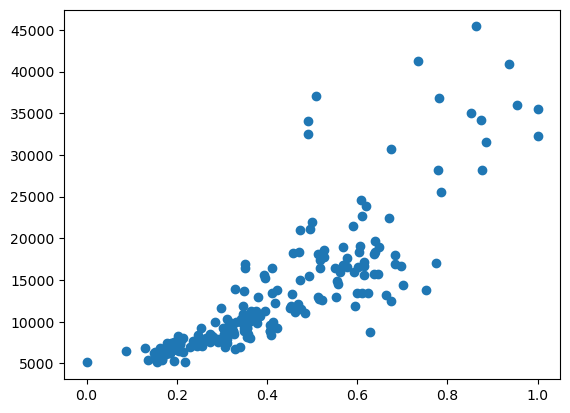

In [53]:
plt.scatter(X[6], y)
plt.show();

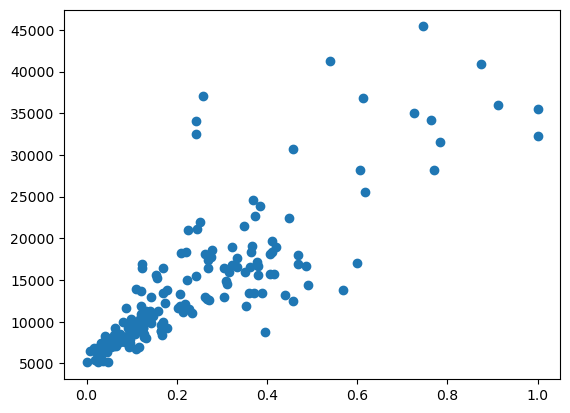

In [55]:
plt.scatter(X[6] ** 2, y)
plt.show();

А для признака номер 13 линеаризовать зависимость получается с помощью функции $\frac 1 {\sqrt{x}}$:

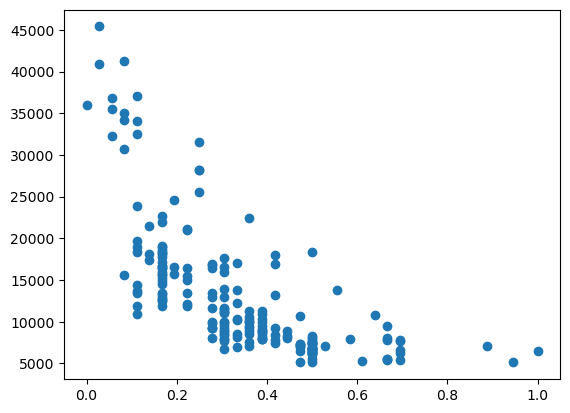

In [58]:
plt.scatter(X[13], y)
plt.show();

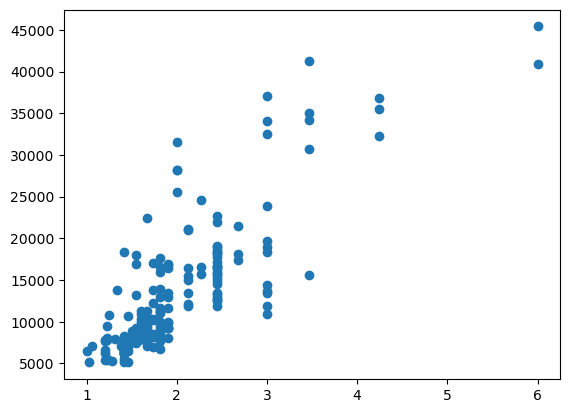

In [60]:
plt.scatter(1 / np.sqrt(X[13]), y)
plt.show();

## 2.  Измерение ошибки в задачах регрессии

Чтобы обучать регрессионные модели, нужно определиться, как именно измеряется качество предсказаний.

Пусть $y$ - значение целевой переменной, $a$ — прогноз модели. Рассмотрим несколько способов оценить отклонение $L(y, a)$ прогноза от истинного ответа.   
$L(y, a)$ называют <u>функцией потерь</u>, задающей <u>штраф</u> за разницу между предсказанием и истинным значением целевого признака. Свойства функции потерь:
* $L(y_i, a(x_i)) \geqslant 0$;
* $L(y_i, y_i) = 0$.



<u>Функционал качества</u> (<u>функционал ошибки</u>) в задачах обучения с учителем обычно задается в виде суммы по объектам выборки:
$$Q(a) = \frac 1 \ell \sum_{i=1}^\ell L(y_i, a(x_i))$$

__Пример:__ если мы не различаем маленькие ошибки (между 0.01 и 0.1 нет особой разницы), но зато не хотим получать большие ошибки, можно использовать следующую функцию потерь:

$$L(y_i, a(x_i)) = [| y_i - a(x_i) | < \varepsilon],$$ $\varepsilon$ — допустимая разница между предсказанием и фактом.

### MSE

$L(y_i, a(x_i)) = (a(x_i) - y_i)^2$

__Среднеквадратичная ошибка (Mean Squared Error, MSE)__: 

$$MSE (a, X) = \frac{1}{l}\sum^l_{i=1}(a(x_i) - y_i)^2$$

MSE не обладает свойством устойчивости к шумовым объектам, потому что задает очень большие штрафы за большие отклонения от фактического значения.

**Пример**. Выберем признак (имеющий индекс 7 в матрице X) и целевой признак (имеющий индекс 15 в матрице X). Добавим к полученной выборке два объекта-выброса и посмотрим, как изменится оптимизированная на MSE прямая.


In [63]:
from sklearn.linear_model import LinearRegression #про линейную регрессию будет ниже 

In [65]:
#Будем предсказывать признак 15 по признаку 7
X_subset = X[[7, 15]].values
X_subset

array([[0.26037736, 0.        ],
       [0.26037736, 0.        ],
       [0.34339623, 0.        ],
       [0.18113208, 1.        ],
       [0.28301887, 1.        ],
       [0.28301887, 1.        ],
       [0.28301887, 1.        ],
       [0.28301887, 1.        ],
       [0.26415094, 1.        ],
       [0.26415094, 1.        ],
       [0.17735849, 0.        ],
       [0.17735849, 0.        ],
       [0.38867925, 0.        ],
       [0.38867925, 0.        ],
       [0.38867925, 0.        ],
       [0.55849057, 0.        ],
       [0.55849057, 0.        ],
       [0.55849057, 0.        ],
       [0.        , 0.        ],
       [0.10943396, 0.        ],
       [0.10943396, 0.        ],
       [0.10943396, 0.        ],
       [0.10943396, 0.        ],
       [0.13962264, 0.        ],
       [0.10943396, 0.        ],
       [0.10943396, 0.        ],
       [0.10943396, 0.        ],
       [0.13962264, 0.        ],
       [0.23018868, 0.        ],
       [0.35849057, 0.        ],
       [0.

In [67]:
#добавление двух шумовых точек (двух выбросов)
X_subset_modified = np.vstack((X_subset, [[1, 90], [2, 50]])) 
X_subset_modified

# np.vstack (от vertical stack) — это функция библиотеки NumPy, 
#которая вертикально соединяет два массива. Она принимает на вход несколько массивов и складывает их друг над другом.

array([[2.60377358e-01, 0.00000000e+00],
       [2.60377358e-01, 0.00000000e+00],
       [3.43396226e-01, 0.00000000e+00],
       [1.81132075e-01, 1.00000000e+00],
       [2.83018868e-01, 1.00000000e+00],
       [2.83018868e-01, 1.00000000e+00],
       [2.83018868e-01, 1.00000000e+00],
       [2.83018868e-01, 1.00000000e+00],
       [2.64150943e-01, 1.00000000e+00],
       [2.64150943e-01, 1.00000000e+00],
       [1.77358491e-01, 0.00000000e+00],
       [1.77358491e-01, 0.00000000e+00],
       [3.88679245e-01, 0.00000000e+00],
       [3.88679245e-01, 0.00000000e+00],
       [3.88679245e-01, 0.00000000e+00],
       [5.58490566e-01, 0.00000000e+00],
       [5.58490566e-01, 0.00000000e+00],
       [5.58490566e-01, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00],
       [1.09433962e-01, 0.00000000e+00],
       [1.09433962e-01, 0.00000000e+00],
       [1.09433962e-01, 0.00000000e+00],
       [1.09433962e-01, 0.00000000e+00],
       [1.39622642e-01, 0.00000000e+00],
       [1.094339

In [69]:
#функция для отрисовки данных
def scatter_points_and_plot_line_MSE(
    X_subset: np.array, ax: matplotlib.axes._axes.Axes
    #X_subset: np.array: Входной параметр, который представляет собой массив, содержащий значения двух переменных 
    #— признака (независимой переменной) и целевой переменной (зависимой переменной).
#ax: matplotlib.axes._axes.Axes: Объект осей matplotlib, на которых будут построены графики.
) -> None:
    # визуализируем точки (признак - таргет)
    ax.scatter(X_subset[:, 0], X_subset[:, 1])
#    X_subset[:, 0]: Это первая колонка массива X_subset, которая содержит значения независимой переменной (признак 7).
# X_subset[:, 1]: Это вторая колонка массива X_subset, которая содержит значения зависимой переменной (признак 15).
#по оси X откладываются значения признака, а по оси Y — значения целевой переменной.
    # обучим линейную модель (обычная линейная регрессия)
    lr = LinearRegression()
    lr.fit(X_subset[:, 0][:, np.newaxis], X_subset[:, 1])
    # X_subset[:, 0][:, np.newaxis]: Преобразуем одномерный массив 
    # (первая колонка) в двумерный массив (вектор-столбец).
#lr.fit(): Метод обучает модель на этих данных, определяя коэффициенты линейной регрессии.
    
    # визуализируем прямую
    grid = np.linspace(0, 2, 100) #точки по оси x 100 in равномерно распред между 0 и 2
    line = lr.predict(grid[:, np.newaxis]) #предсказанные значения, Метод возвращает предсказанные значения на основе модели.
    ax.plot(grid, line) #  Рисуем линию, используя предсказанные значения. Она показывает тренд линейной регрессии, основанный на обученных данных 
    ax.set_ylim(-20, 100) # диапазон значений такой чтобы увидеть доб точки
    ax.set_xlabel("x")
    ax.set_ylabel("y")

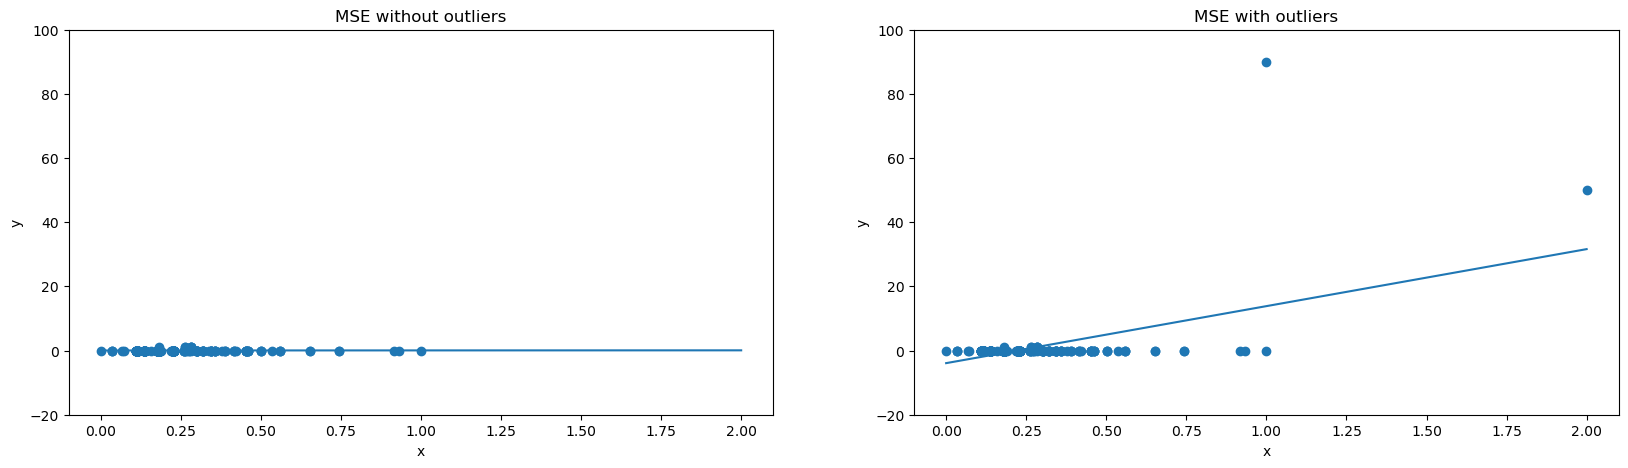

In [71]:
_, ax = plt.subplots(1, 2, figsize=(20, 5))
ax[0].set_title("MSE without outliers") #без выбросов
scatter_points_and_plot_line_MSE(X_subset, ax[0])
ax[1].set_title("MSE with outliers")   #с выбросами
scatter_points_and_plot_line_MSE(X_subset_modified, ax[1])
plt.show();

**Задание.** Реализуйте функцию для подсчета MSE с использованием numpy.

In [75]:
def MSE(y: np.array, y_pred: np.array) -> np.float64:
    # <YOUR CODE HERE>
    return ((y-y_pred)**2).mean()


a = np.array([11, 20, 19, 17, 10])
pred = np.array([12, 18, 19.5, 18, 9])
mse = MSE(y=a, y_pred=pred)
print(f"Mean Square Error is: {mse}")
assert mse == 1.45

Mean Square Error is: 1.45


Альтернативный вариант (sklearn):

In [78]:
from sklearn.metrics import mean_squared_error

In [80]:
print(f"Mean Square Error is: {mean_squared_error(a, pred)}")

Mean Square Error is: 1.45


In [82]:
mean_squared_error?

Signature:
mean_squared_error(
    y_true,
    y_pred,
    *,
    sample_weight=None,
    multioutput='uniform_average',
    squared='deprecated',
)
Docstring:
Mean squared error regression loss.

Read more in the :ref:`User Guide <mean_squared_error>`.

Parameters
----------
y_true : array-like of shape (n_samples,) or (n_samples, n_outputs)
    Ground truth (correct) target values.

y_pred : array-like of shape (n_samples,) or (n_samples, n_outputs)
    Estimated target values.

sample_weight : array-like of shape (n_samples,), default=None
    Sample weights.

multioutput : {'raw_values', 'uniform_average'} or array-like of shape             (n_outputs,), default='uniform_average'
    Defines aggregating of multiple output values.
    Array-like value defines weights used to average errors.

    'raw_values' :
        Returns a full set of errors in case of multioutput input.

    'uniform_average' :
        Errors of all outputs are averaged with uniform weight.

squared : bool, de

*__Примечание__. Если использовать MSE как функционал качества (для обучения), то в формуле для MSE на $l$ можно не делить.
Если использовать MSE как метрику качества (для оценки качества модели), то в формуле для MSE нужно деление на $l$, и лучше
извлекать корень из MSE, т.е. иcпользовать метрику RMSE.*

### RMSE

Среднеквадратичная ошибка подходит для сравнения двух моделей или для контроля качества во время обучения. Из-за того, что разница возводится в квадрат, сложно дать этому числу интерпретацию. 

Для лучшей интерпретации используется __Root Mean Square Error (RMSE)__: её значение имеет те же масштабы, что и целевая переменная.

$$RMSE (a, X) = \sqrt{MSE (a, X)} = \sqrt{ \sum^l_{i=1}(a(x_i) - y_i)^2}$$

**Задание.** Реализуйте функцию для подсчета RMSE с использованием numpy.

In [86]:
def RMSE(y: np.array, y_pred: np.array) -> np.float64:
    # <YOUR CODE HERE>
    return np.sqrt(MSE(y,y_pred))

rmse = RMSE(y=a, y_pred=pred)
print(f"Root Mean Square Error is: {rmse}")
assert rmse == 1.2041594578792296

Root Mean Square Error is: 1.2041594578792296


### $R^2$

__Коэффициент детерминации $R^2$__ показывает долю дисперсии в целевой переменной, которая объяснена зависимыми переменными.   ($R^2$ можно интерпретировать как некоторого рода нормированное MSE).

$$R^2(a, X, Y) = 1 - \frac {\sum^L_{i=1}(a(x_i) - y_i)^2}{\sum^L_{i=1}(y_i - \bar{y})^2}$$ или 
$$R^2(a, X, Y) = 1 - \frac {\frac{1}{l}\sum^l_{i=1}(a(x_i) - y_i)^2}{\frac{1}{l}\sum^l_{i=1}(y_i - \bar{y})^2}$$
- Если $R^2 < 0$, значит наша модель даёт предсказание хуже константы в виде среднего значения целевой переменной, то есть абсолютно бесполезна с точки зрения MSE.
- Если $R^2 = 0$, значит мы предсказываем не лучше и не хуже константы в виде среднего значения целевой переменной.
- Если $0 < R^2 < 1$, значит модель работает лучше константного предсказания с точки зрения MSE.
- Если $R^2 = 1$, значит ошибка MSE равна нулю. 

**Задание.** Реализуйте функцию для подсчета $R^2$ с использованием numpy.

In [89]:
def R_squared(y: np.array, y_pred: np.array) -> np.float64:
    # <YOUR CODE HERE>
    std = ((y - np.mean(y))**2).mean()
    return 1 - MSE(y,y_pred)/std


r_squared = R_squared(y=a, y_pred=pred)
print(f"R2 score is: {r_squared}")

R2 score is: 0.914906103286385


Альтернативный вариант (sklearn):

In [92]:
from sklearn.metrics import r2_score

In [94]:
print(f"r2_score is: {r2_score(a, pred)}")

r2_score is: 0.914906103286385


### MAE

$L(y_i, a(x_i)) = |a(x_i) - y_i|$

__Средняя абсолютная ошибка (Mean Absolute Error, MAE)__:

$$MAE(a, X) = \frac {1}{l} \sum^l_{i=1}|a(x_i) - y_i|$$

Из-за того, что в MSE мы учитываем квадрат отклонения, шумовые объекты могут сильно изменить наклон прямой. Поэтому в качестве альтернативы MSE можно использовать MAE.

**Задание.** Реализуйте функцию для подсчета MAE с использованием numpy.

In [97]:
def MAE(y: np.array, y_pred: np.array) -> np.float64:
    # <YOUR CODE HERE>
    return np.abs(y-y_pred).mean()


mae = MAE(y=a, y_pred=pred)
print(f"Mean Absolute Error is: {mae}")
assert mae == 1.1

Mean Absolute Error is: 1.1


Альтернативный вариант (sklearn):

In [100]:
from sklearn.metrics import mean_absolute_error

In [102]:
print(f"MAE is: {mean_absolute_error(a, pred)}")

MAE is: 1.1


---

### Дополнительно

<u>Можно обучить регрессию, оптимизируя MAE (а не MSE)</u>. В `sklearn` такая регрессия не реализована, но можно использовать модуль `statsmodels` (для работы со статистическими моделями). Более формально, необходимая модель может быть получена с помощью обучения <u>квантильной регрессии</u> с параметром `q=0.5`.

In [107]:
# !pip install git+https://github.com/statsmodels/statsmodels 
#(если не работает импортирование библиотек ниже)

In [109]:
import statsmodels.formula.api as smf #синтаксис похож на R 
#Импорт библиотеки statsmodels, используется для статистического анализа, в том числе для квантильной регрессии.

In [111]:
#Эта функция создает диаграмму рассеяния (график разброса точек) и строит линию на основе квантильной регрессии для минимизации ошибок (MAE).
#Принимает два аргумента: массиов данных и построение графиков
def scatter_points_and_plot_line_MAE(
    X_subset: np.array, ax: matplotlib.axes._axes.Axes
) -> None:
    # задаем зависимость переменной f15 от переменной f7 и передаем данные
    mod = smf.quantreg("f15 ~ f7", pd.DataFrame(data=X_subset, columns=["f7", "f15"])) #квантильная регрессия 
#smf.quantreg: Создает объект модели квантильной регрессии. 

    res = mod.fit(q=0.5) #q=0.5 - это минимизация MAE
#	mod.fit(q=0.5): Обучаем модель квантильной регрессии, минимизируя медианное отклонение (квантиль 0,5), 
    #что соответствует минимизации средней абсолютной ошибки (MAE). В результате получения объекта res, 
    #включаются параметры обученной модели.

    # визуализируем точки
    ax.scatter(X_subset[:, 0], X_subset[:, 1])
 
    # визуализируем прямую
    grid = np.linspace(0, 2, 100)
    #Создаем набор результатов по оси X для визуализации линий регрессии. 
    #Значения различаются от 0 до 2 (100 точек).
    line = grid * res.params["f7"] + res.params["Intercept"]
    #Intercept свободный член уравнения регрессии.
    #Рассчитываем предсказанные значения по оси Y для линии регрессии. 

    ax.plot(grid, line)
    #Строим линию регрессии на графике
    ax.set_ylim(-20, 100)
    #Устанавливаем углы по оси Y от -20 до 100.
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    #Установка осей

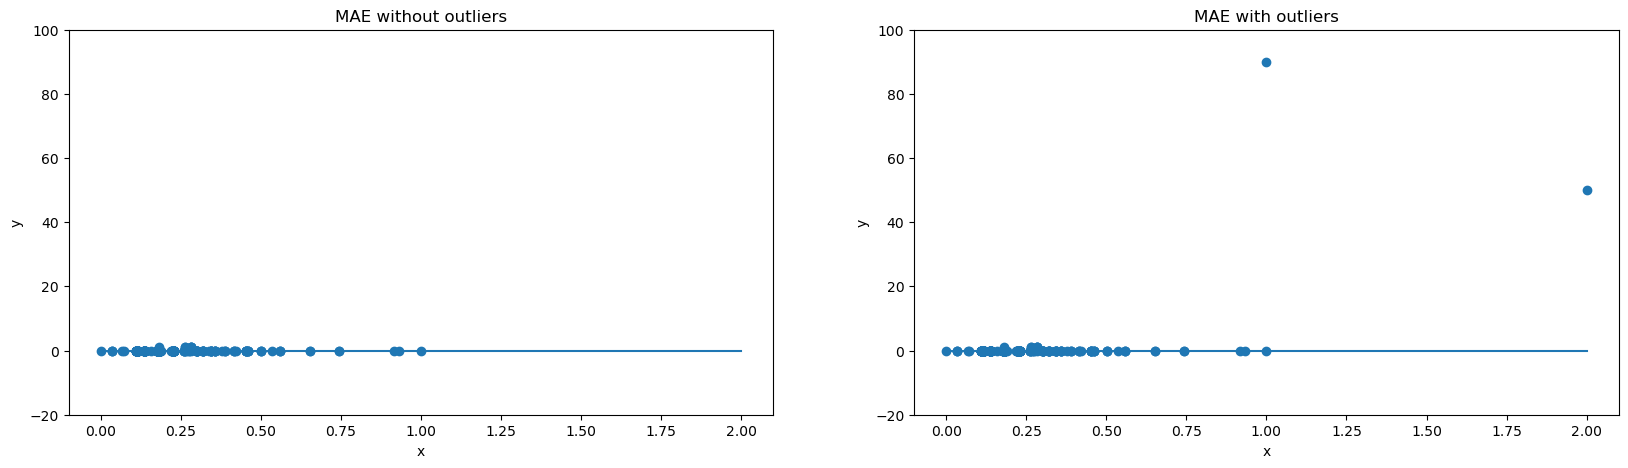

In [272]:
_, ax = plt.subplots(1, 2, figsize=(20, 5))
#Создаем две области для графиков 
ax[0].set_title("MAE without outliers")
#Устанавливаем заголовок для первой графики (данные без восстановления).
scatter_points_and_plot_line_MAE(X_subset, ax[0])
#Визуализируемый график без восстановления.
ax[1].set_title("MAE with outliers")
#Устанавливаем заголовок для второй графики (данные с выбросами).
scatter_points_and_plot_line_MAE(X_subset_modified, ax[1])
#Визуализируемый график с выбросами.
plt.show();
#Показываем графики.

Прямая практически не изменила направление из-за выбросов! Попробуем добавить больше шумовых объектов.

In [274]:
np.random.randint(5, size=60).reshape(-1, 2)* [1, 30] #поэлементное умножение 
#Генерируемый массив из 60 случайных целых чисел от 0 до 4.
#Преобразуем этот массив в двумерный массив с двумя столбцами.
#Поэлементно умножаем столбцы массива. 
#Первый столбец умножаем на 1 (поставляется как есть), а второй — на 30.

array([[  2,  90],
       [  4,  90],
       [  4,  30],
       [  2,   0],
       [  1,  60],
       [  3, 120],
       [  0, 120],
       [  3,  30],
       [  0,  30],
       [  2, 120],
       [  3, 120],
       [  2, 120],
       [  2,  30],
       [  0,   0],
       [  3, 120],
       [  2, 120],
       [  1,  30],
       [  1,  90],
       [  2, 120],
       [  0,  90],
       [  1,  30],
       [  2,  90],
       [  2, 120],
       [  0,  30],
       [  4,   0],
       [  3,  30],
       [  4,  30],
       [  0, 120],
       [  3,  60],
       [  4, 120]])

In [118]:
#Устанавливаем фиксированное значение для генератора случайных чисел (чтобы результаты были воспроизведены).
np.random.seed(13)
#Создаем новый набор данных 
X_subset_modified_twice = np.vstack(
#X_subset_modified_twice, включающий X_subset_modified еще несколько случайных выбросов, сгенерированных на предыдущем этапе.
    (X_subset_modified, np.random.randint(5, size=60).reshape(-1, 2) * [1, 30])
)


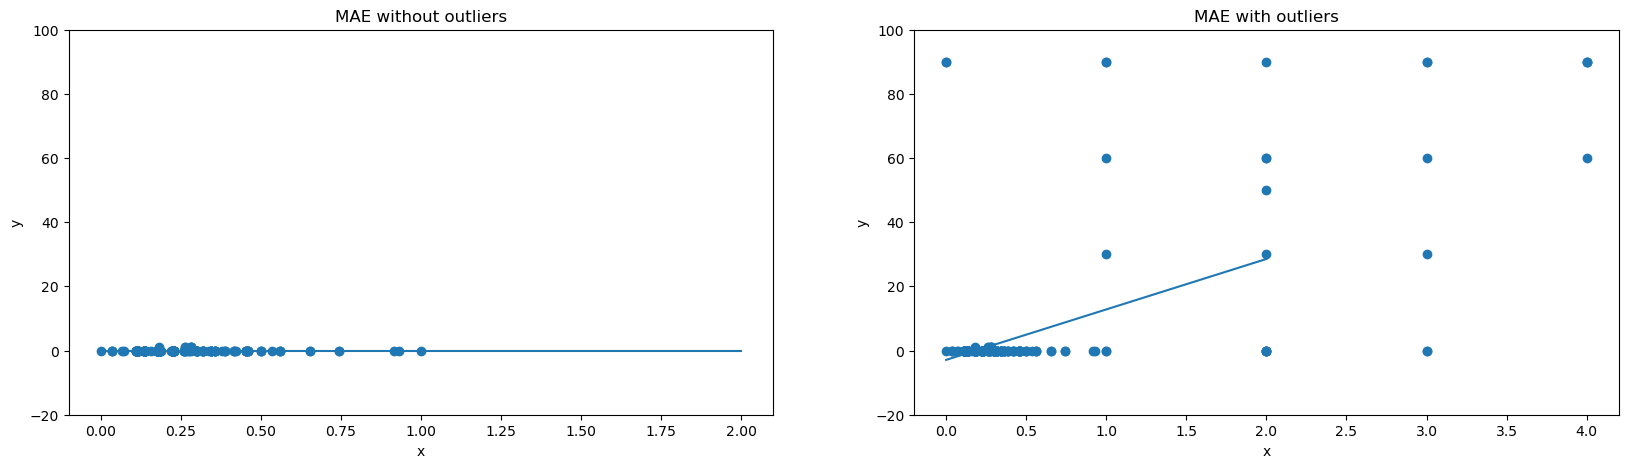

In [120]:
_, ax = plt.subplots(1, 2, figsize=(20, 5))
ax[0].set_title("MAE without outliers")
scatter_points_and_plot_line_MAE(X_subset, ax[0])
ax[1].set_title("MAE with outliers")
scatter_points_and_plot_line_MAE(X_subset_modified_twice, ax[1])
plt.show();

Под таким количеством выбросов, изменилась даже регрессия над MAE.

---

### Оптимальные константы для MSE и MAE

Допустим, все $l$ объектов выборки имеют одинаковые признаковые описания, но разные значения целевой переменной $y_1,...,y_l$. В этом случае модель должна на всех объектах выдать один и тот же ответ, т.е. алгоритм возвращает константное предсказание: $a(x) = C, C \in R$.  
(В качестве примера такого алгоритма можно представить предсказание прибыли в январе константой, равной средней прибыли за январь всех предыдущих лет работы).

**Задание.** Найдите $C$, минимизирующий среднеквадратичную ошибку.

**Решение.** Нам необходимо найти константу C, минимизирующую функцию $\frac{1}{n} \sum_{i}^{n} (C - y_i)^2$. Для этого возьмём производную этой функции и приравняем её к нулю: $\frac{2}{n}\sum_{i}^{n} (C - y_i) = 0$. Преобразуем это выражение и выпишем ответ: $C = \frac{\sum_{i}^{n} y_i}{n}$. То есть <u>оптимальная константа</u> — <u>среднее значение целевой переменной</u>.

**Задание.** Найдите $C$, минимизирующий среднюю абсолютную ошибку.


## 3. Обучение линейных моделей

**Линейная регрессия** `sklearn.linear_model.LinearRegression` (в общем случае **метод наименьших квадратов, МНК**) - минимизация суммы кадратов разностей ответов $y_i$ и их приближений $a(x_i)$.   
$a(x_i)$ - приближение линейной моделью: 
$a(x)=  w_0+w_1x_1+...w_lx_l$.

Требуется найти $w_0, w_1,...,w_l$ так, чтобы выполнялось условие:
$$
Q(a,X)=\sum_{i=1}^{l}(y_i-a(x_i))^2
\rightarrow min_{w_0,w_1,...,w_l}
$$
или
$$
Q(w,X)=
\sum_{i=1}^{l}(<w,x_i>-y_i)^2\rightarrow min_{w_0,w_1,...,w_l}
$$
В матричной форме записи (почему ???):
$$
Q(w,X)=\|Xw-y\|^2\rightarrow min_{w}
$$
Дифференцируем $Q$ по параметрам $w_0,w_1,...,w_l$ и получаем, что (вычислите !!!):  
$$ 
\nabla_wQ(w,X)=2X^T(Xw-y)=0
$$
Аналитическое решение задачи линейной регрессии:
$$
w^*=(X^TX)^{-1}X^Ty
$$




Частный случай: **парная регрессия**: $a(x)=  w_0+w_1x_1$, 
$$
Q(w_0,w_1,X)=
\sum_{i=1}^{l}(w_1x_i+w_0-y_i)^2\rightarrow min_{w_0,w_1}
$$
$\frac{\partial Q}{\partial w_1}=2\sum_{i=1}^{l}(w_1x_i+w_0-y_i)x_i$,

$\frac{\partial Q}{\partial w_0}=2\sum_{i=1}^{l}(w_1x_i+w_0-y_i)x_i$

Выпишите формулы для $w_1$ и $w_0$.


**Пример 1 ("игрушечный" пример)**. Предсказание линейной моделью (МНК) по трем признакам. (https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression)

$y=1 \cdot x_0 +2\cdot x_1 +3$ - искомая (приближаемая) функция (вообще говоря, неизвестна).

Дано:

$X=\begin{pmatrix}
  1&1&1\\
  1&2&1\\
  2&2&1\\
  2&3&1\\
\end{pmatrix}$ - матрица "объект-признак" (третий признак = 1 для всех объектов), 
$y=\begin{pmatrix}
  6\\
  8\\
  9\\
  11\\
\end{pmatrix}
$ - ответы

Найти функцию $a(x)$, приближающую $y$: $a(x)=w_0 \cdot x_0 +w_1\cdot x_1 +w_2$

Результат (обучения):

$w=\begin{pmatrix}
  1\\
  2\\
  3\\
\end{pmatrix}
$ - искомые веса,
следовательно, $a(x)=1 \cdot x_0 +2\cdot x_1 +3$

Применение полученной модели к новому объекту $x=(x_0, x_1)$:

$a(x_0=3, x_1=5)=1 \cdot 3 +2\cdot 5 +3=16$

**Способ 1 (с помощью LinearRegression())**


In [129]:
X = np.array([[1, 1], 
              [1, 2], 
              [2, 2], 
              [2, 3]]) #признаки 4-х объектов
print('X=',X)
# y = 1 * x_0 + 2 * x_1 + 3 #
y = np.dot(X, np.array([1, 2])) + 3  #целевая переменная
print('y=',y)
lr = LinearRegression() #создаем регрессор
reg = lr.fit(X, y)    #обучение 
print('r2=',reg.score(X, y)) #the coefficient of determination of the prediction
                       #(1 - \frac{u}{v})`
#1.0
print('w0,w1=', reg.coef_)     #искомые параметры w1,w2 
#array([1., 2.])
print('w2=',reg.intercept_) #искомый параметр сдвиг w0
#3.0...
print('a([3, 5])=',reg.predict(np.array([[3, 5]]))) #предсказание для нового объекта x
#array([16.])

X= [[1 1]
 [1 2]
 [2 2]
 [2 3]]
y= [ 6  8  9 11]
r2= 1.0
w0,w1= [1. 2.]
w2= 3.0000000000000018
a([3, 5])= [16.]


In [131]:
reg.score?

Signature: reg.score(X, y, sample_weight=None)
Docstring:
Return the coefficient of determination of the prediction.

The coefficient of determination :math:`R^2` is defined as
:math:`(1 - \frac{u}{v})`, where :math:`u` is the residual
sum of squares ``((y_true - y_pred)** 2).sum()`` and :math:`v`
is the total sum of squares ``((y_true - y_true.mean()) ** 2).sum()``.
The best possible score is 1.0 and it can be negative (because the
model can be arbitrarily worse). A constant model that always predicts
the expected value of `y`, disregarding the input features, would get
a :math:`R^2` score of 0.0.

Parameters
----------
X : array-like of shape (n_samples, n_features)
    Test samples. For some estimators this may be a precomputed
    kernel matrix or a list of generic objects instead with shape
    ``(n_samples, n_samples_fitted)``, where ``n_samples_fitted``
    is the number of samples used in the fitting for the estimator.

y : array-like of shape (n_samples,) or (n_samples, n_outp

**Способ 2: формула** $$
w^*=(X^TX)^{-1}X^Ty
$$

In [134]:
X = np.array([[1, 1], [1, 2], [2, 2], [2, 3]])
print('X=',X)
y = np.dot(X, np.array([1, 2])) + 3
print('y=',y)
X3 = np.array([[1], [1], [1], [1]])
print('X3=',X3)
X_mod = np.hstack([X, X3])
print('X_mod=',X_mod)
w= np.linalg.inv(X_mod.T@X_mod)@X_mod.T@y #формула w
print('w=',w)

X= [[1 1]
 [1 2]
 [2 2]
 [2 3]]
y= [ 6  8  9 11]
X3= [[1]
 [1]
 [1]
 [1]]
X_mod= [[1 1 1]
 [1 2 1]
 [2 2 1]
 [2 3 1]]
w= [1. 2. 3.]


**Пример 2 (парная регрессия)**. Предсказание линейной моделью (МНК) - на наборе данных по диабету. (https://scikit-learn.org/stable/auto_examples/linear_model/plot_ols.html#sphx-glr-auto-examples-linear-model-plot-ols-py)

In [137]:
# Code source: Jaques Grobler
# License: BSD 3 clause

import matplotlib.pyplot as plt
import numpy as np

from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score

# Load the diabetes dataset
diabetes_X, diabetes_y = datasets.load_diabetes(return_X_y=True)
print(diabetes_X.shape)


(442, 10)


In [139]:
# Use only one feature (столбец №2)
diabetes_X = diabetes_X[:, np.newaxis, 2]

# Split the data into training/testing sets
diabetes_X_train = diabetes_X[:-20]
diabetes_X_test = diabetes_X[-20:]

# Split the targets into training/testing sets
diabetes_y_train = diabetes_y[:-20]
diabetes_y_test = diabetes_y[-20:]

Coefficients: 
 [938.23786125]
Mean squared error: 2548.07
Coefficient of determination: 0.47


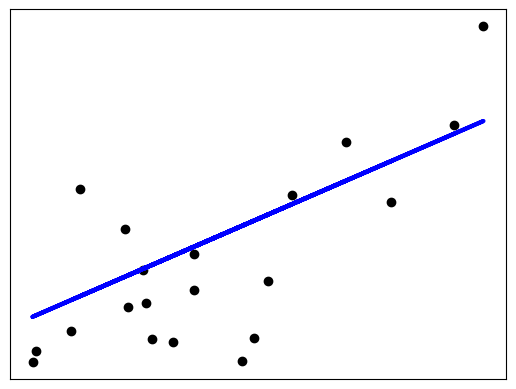

In [141]:
# Create linear regression object
regr = linear_model.LinearRegression()

# Train the model using the training sets
regr.fit(diabetes_X_train, diabetes_y_train)

# Make predictions using the testing set
diabetes_y_pred = regr.predict(diabetes_X_test)

# The coefficients
print("Coefficients: \n", regr.coef_)
# The mean squared error
print("Mean squared error: %.2f" % mean_squared_error(diabetes_y_test, diabetes_y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(diabetes_y_test, diabetes_y_pred))

# Plot outputs
plt.scatter(diabetes_X_test, diabetes_y_test, color="black")
plt.plot(diabetes_X_test, diabetes_y_pred, color="blue", linewidth=3)

plt.xticks(())
plt.yticks(())

plt.show()

## Задача (данные о сообществах в США)



Рассмортрим данные о сообществах в США. 

Будем предсказывать количество насильственных преступлений относительно численности населения.

[Описание датасета](http://archive.ics.uci.edu/ml/datasets/communities+and+crime)
[Датасет на кэггле](https://www.kaggle.com/kkanda/communities%20and%20crime%20unnormalized%20data%20set)

In [195]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt


In [197]:
# LinearRegression: класс для создания модели линейной регрессии.
from sklearn.linear_model import LinearRegression

In [199]:
#Lasso и Ridge: классы линейных моделей с регуляризацией (Lasso для L1-регуляризации, Ridge для L2-регуляризации).
from sklearn.linear_model import Lasso, Ridge
#mean_squared_error функция для расчета среднеквадратичной ошибки.
from sklearn.metrics import mean_squared_error 
#train_test_split: функция для разбиения данных на обучающую и тестовую выборки.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

### 0. Смотрим на данные (без предобработки)

In [202]:
data = pd.read_csv("crimedata.csv", na_values=["?"])
data.head()

,communityname,state,countyCode,communityCode,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,...,burglaries,burglPerPop,larcenies,larcPerPop,autoTheft,autoTheftPerPop,arsons,arsonsPerPop,ViolentCrimesPerPop,nonViolPerPop
0,BerkeleyHeightstownship,NJ,39.0,5320.0,1,11980,3.10,1.37,91.78,6.50,...,14.0,114.85,138.0,1132.08,16.0,131.26,2.0,16.41,41.02,1394.59
1,Marpletownship,PA,45.0,47616.0,1,23123,2.82,0.80,95.57,3.44,...,57.0,242.37,376.0,1598.78,26.0,110.55,1.0,4.25,127.56,1955.95
2,Tigardcity,OR,NaN,NaN,1,29344,2.43,0.74,94.33,3.43,...,274.0,758.14,1797.0,4972.19,136.0,376.30,22.0,60.87,218.59,6167.51
3,Gloversvillecity,NY,35.0,29443.0,1,16656,2.40,1.70,97.35,0.50,...,225.0,1301.78,716.0,4142.56,47.0,271.93,NaN,NaN,306.64,NaN
4,Bemidjicity,MN,7.0,5068.0,1,11245,2.76,0.53,89.16,1.17,...,91.0,728.93,1060.0,8490.87,91.0,728.93,5.0,40.05,NaN,9988.79


In [24]:
data.shape

(2215, 147)

In [98]:
# оставим лишь нужные колонки
#requiredColumns: создается список индексов нужных столбцов, включая определенные диапазоны.
requiredColumns = [5, 6] + list(range(11, 26)) + list(range(32, 103)) + [145] 
#номера колонок
data.columns[requiredColumns]  #названия этих колонок в датасете
data = data[data.columns[requiredColumns]] #эти колонки в датасете
data#.head()

,population,householdsize,agePct12t21,agePct12t29,agePct16t24,agePct65up,numbUrban,pctUrban,medIncome,pctWWage,...,MedOwnCostPctInc,MedOwnCostPctIncNoMtg,NumInShelters,NumStreet,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,ViolentCrimesPerPop
0,11980,3.10,12.47,21.44,10.93,11.33,11980,100.00,75122,89.24,...,21.1,14.0,11,0,10.66,53.72,65.29,78.09,89.14,41.02
1,23123,2.82,11.01,21.30,10.48,17.18,23123,100.00,47917,78.99,...,20.7,12.5,0,0,8.30,77.17,71.27,90.22,96.12,127.56
2,29344,2.43,11.36,25.88,11.01,10.28,29344,100.00,35669,82.00,...,21.7,11.6,16,0,5.00,44.77,36.60,61.26,82.85,218.59
3,16656,2.40,12.55,25.20,12.19,17.57,0,0.00,20580,68.15,...,20.6,14.5,0,0,2.04,88.71,56.70,90.17,96.24,306.64
4,11245,2.76,24.46,40.53,28.69,12.65,0,0.00,17390,69.33,...,23.2,12.9,2,0,1.74,73.75,42.22,60.34,89.02,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2210,56216,3.07,15.46,30.16,14.34,8.08,56216,100.00,24727,75.05,...,22.6,11.7,64,0,18.90,52.67,39.19,74.58,85.88,545.75
2211,12251,2.68,17.36,31.23,16.97,12.57,12251,100.00,20321,75.06,...,17.3,14.4,0,0,2.24,75.16,49.12,78.79,92.85,124.10
2212,32824,2.46,11.81,20.96,9.53,20.73,32824,100.00,27182,59.79,...,23.9,13.1,44,0,7.35,48.66,46.73,75.54,92.30,353.83
2213,13547,2.89,17.16,30.01,14.73,10.42,0,0.00,19899,71.67,...,23.3,14.1,0,0,2.28,82.26,54.05,79.72,94.06,691.17


In [28]:
# некоторые значения целевой переменной "ViolentCrimesPerPop" пропущены
#выбираем строки, где нет пропусков в "ViolentCrimesPerPop"
data.loc[data["ViolentCrimesPerPop"].notnull(), :]

,population,householdsize,agePct12t21,agePct12t29,agePct16t24,agePct65up,numbUrban,pctUrban,medIncome,pctWWage,...,MedOwnCostPctInc,MedOwnCostPctIncNoMtg,NumInShelters,NumStreet,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,ViolentCrimesPerPop
0,11980,3.10,12.47,21.44,10.93,11.33,11980,100.00,75122,89.24,...,21.1,14.0,11,0,10.66,53.72,65.29,78.09,89.14,41.02
1,23123,2.82,11.01,21.30,10.48,17.18,23123,100.00,47917,78.99,...,20.7,12.5,0,0,8.30,77.17,71.27,90.22,96.12,127.56
2,29344,2.43,11.36,25.88,11.01,10.28,29344,100.00,35669,82.00,...,21.7,11.6,16,0,5.00,44.77,36.60,61.26,82.85,218.59
3,16656,2.40,12.55,25.20,12.19,17.57,0,0.00,20580,68.15,...,20.6,14.5,0,0,2.04,88.71,56.70,90.17,96.24,306.64
5,140494,2.45,18.09,32.89,20.04,13.26,140494,100.00,21577,75.78,...,17.3,11.7,327,4,1.49,64.35,42.29,70.61,85.66,442.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2210,56216,3.07,15.46,30.16,14.34,8.08,56216,100.00,24727,75.05,...,22.6,11.7,64,0,18.90,52.67,39.19,74.58,85.88,545.75
2211,12251,2.68,17.36,31.23,16.97,12.57,12251,100.00,20321,75.06,...,17.3,14.4,0,0,2.24,75.16,49.12,78.79,92.85,124.10
2212,32824,2.46,11.81,20.96,9.53,20.73,32824,100.00,27182,59.79,...,23.9,13.1,44,0,7.35,48.66,46.73,75.54,92.30,353.83
2213,13547,2.89,17.16,30.01,14.73,10.42,0,0.00,19899,71.67,...,23.3,14.1,0,0,2.28,82.26,54.05,79.72,94.06,691.17


In [100]:
# матрица объект-признак (выбрасываем столбец "ViolentCrimesPerPop")
X = data.loc[data["ViolentCrimesPerPop"].notnull(), :].drop(
    "ViolentCrimesPerPop", axis=1
) #новый DataFrame, содержащий только строки с ненулевыми значениями 
#в столбце "ViolentCrimesPerPop". 


In [104]:
X.shape

(1994, 88)

In [106]:
X.index #индексы строк, которые вошли в X

Index([   0,    1,    2,    3,    5,    6,    7,    8,    9,   10,
       ...
       2205, 2206, 2207, 2208, 2209, 2210, 2211, 2212, 2213, 2214],
      dtype='int64', length=1994)

In [108]:
#целевая переменная "ViolentCrimesPerPop" с индексами X
y = data["ViolentCrimesPerPop"][X.index] 
y.head()
#y - похож на логнормальное распределение (гистограмма ниже) - можно так оставить 
# np.log1p(y) = log(1 + y) - уже нормальное распределение - или можно применить np.log1p


0     41.02
1    127.56
2    218.59
3    306.64
5    442.95
Name: ViolentCrimesPerPop, dtype: float64

In [168]:
y.shape

(1994,)

(array([1.173e+03, 4.440e+02, 1.950e+02, 9.500e+01, 4.500e+01, 2.100e+01,
        1.200e+01, 6.000e+00, 2.000e+00, 1.000e+00]),
 array([   0.   ,  487.706,  975.412, 1463.118, 1950.824, 2438.53 ,
        2926.236, 3413.942, 3901.648, 4389.354, 4877.06 ]),
 <BarContainer object of 10 artists>)

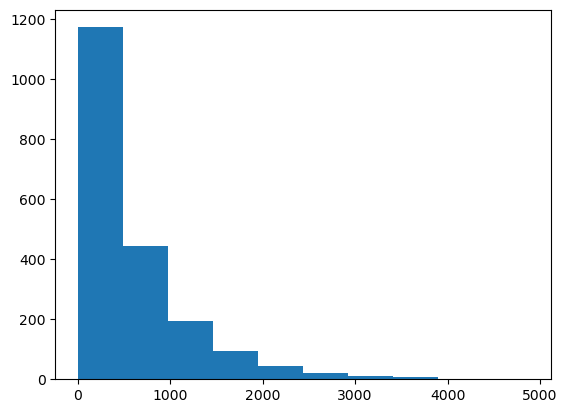

In [112]:
#Построение гистограммы для целевой переменной, чтобы понять её
#распределение. Это помогает решить, нужно ли преобразование для
#нормализации данных.
plt.hist(y) 
# plt.hist(np.log1p(y)) #можно применить

In [114]:
np.log1p?

Signature:       np.log1p(*args, **kwargs)
Type:            ufunc
String form:     <ufunc 'log1p'>
File:            /opt/anaconda3/lib/python3.12/site-packages/numpy/__init__.py
Docstring:      
log1p(x, /, out=None, *, where=True, casting='same_kind', order='K', dtype=None, subok=True[, signature, extobj])

Return the natural logarithm of one plus the input array, element-wise.

Calculates ``log(1 + x)``.

Parameters
----------
x : array_like
    Input values.
out : ndarray, None, or tuple of ndarray and None, optional
    A location into which the result is stored. If provided, it must have
    a shape that the inputs broadcast to. If not provided or None,
    a freshly-allocated array is returned. A tuple (possible only as a
    keyword argument) must have length equal to the number of outputs.
where : array_like, optional
    This condition is broadcast over the input. At locations where the
    condition is True, the `out` array will be set to the ufunc result.
    Elsewhere, the 

In [116]:
#разбиваем на train и test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.25)

In [118]:
X_train.shape, X_test.shape

((1495, 88), (499, 88))

In [120]:
X_train

,population,householdsize,agePct12t21,agePct12t29,agePct16t24,agePct65up,numbUrban,pctUrban,medIncome,pctWWage,...,MedRentPctHousInc,MedOwnCostPctInc,MedOwnCostPctIncNoMtg,NumInShelters,NumStreet,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85
603,21128,2.50,13.09,25.19,12.81,14.55,21128,100.0,25547,71.79,...,24.5,15.2,11.7,0,0,2.25,74.47,63.00,91.98,96.22
590,15791,3.42,17.55,32.30,17.00,10.11,0,0.0,24128,77.29,...,29.1,22.1,11.0,0,0,28.40,50.62,45.21,79.38,90.01
1649,64989,2.59,12.89,29.89,14.92,10.57,64972,100.0,42948,84.20,...,25.7,21.4,13.6,92,0,11.70,62.45,55.47,78.51,87.73
1325,35800,2.53,12.89,28.06,12.42,6.05,35800,100.0,42299,89.74,...,24.7,20.5,11.9,0,0,9.57,39.82,36.90,68.33,76.63
1250,16032,2.53,11.91,23.09,10.78,15.49,15995,100.0,36977,75.03,...,23.9,17.0,11.6,0,0,0.76,63.54,61.90,84.59,90.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
932,17301,2.74,13.96,23.08,10.97,10.20,17301,100.0,46353,81.62,...,24.1,19.4,12.2,0,0,2.94,68.08,49.71,82.44,87.58
1358,33687,2.43,10.50,24.43,11.32,16.51,0,0.0,35230,76.35,...,24.6,24.2,14.0,5,0,6.77,73.23,57.80,87.32,92.62
1845,19513,2.76,13.71,27.38,12.38,7.57,19513,100.0,39995,86.21,...,22.8,19.5,13.0,0,0,2.74,81.22,59.29,87.82,94.57
624,14967,2.60,13.56,26.03,11.61,7.51,14967,100.0,36999,86.99,...,24.5,21.7,11.7,0,0,1.51,70.08,49.25,77.25,88.56


In [122]:
#среднее значение (для инф-ии)
y.mean()

589.078921765296

### 1. Baseline ("стартовая точка" - без предобработки)
Обучим линейную регрессию и выведем качество по метрике MSE (RMSE) на обучающей и тестовой выборке.

In [65]:
from sklearn.metrics import r2_score

In [124]:
lr = LinearRegression() #создаем регрессор
lr.fit(X_train, y_train) #обучение

pred_train = lr.predict(X_train) #предсказание
pred_test = lr.predict(X_test)   #предсказание

print(f"Train: {mean_squared_error(y_train, pred_train)**0.5}") #**0.5 берется для извлечения корня
print(f"Test: {mean_squared_error(y_test, pred_test)**0.5}")    #**0.5

r2_score(y_train, pred_train), r2_score(y_test, pred_test)

Train: 346.31763763587725
Test: 454.9493206641272


(0.6731208442568581, 0.49554452281241046)

(array([ 2.,  1.,  8., 73.,  3.,  0.,  0.,  0.,  0.,  1.]),
 array([-329.61300718, -228.38184662, -127.15068607,  -25.91952551,
          75.31163505,  176.5427956 ,  277.77395616,  379.00511672,
         480.23627727,  581.46743783,  682.69859839]),
 <BarContainer object of 10 artists>)

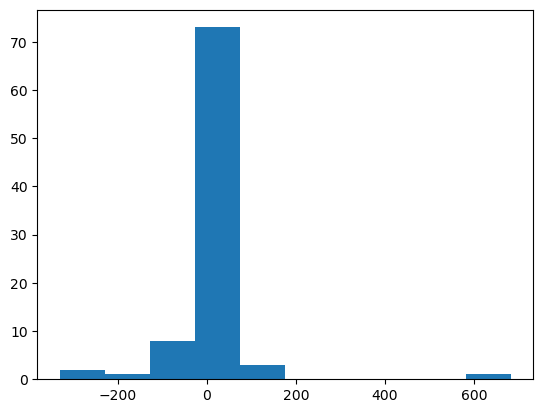

In [126]:
#веса модели
plt.hist(lr.coef_)

Признаки переобучения:
- ошибка на test гораздо больше, чем ошибка на train
- есть большие веса

Популярным решением для регрессионных моделей является **регуляризация**.

Во время оптимизации линейной регрессии, веса при переменных могут получиться большими в абсолютных значениях. Это не очень хорошо, поскольку классификатор будет чувствителен к крайне маленьким изменениям в признаках объекта, а значит, переобучен. Для решения проблемы к функционалу ошибки добавляют регуляризатор, который "штрафует" модель за слишком большую норму вектора весов:

$$Q_\alpha(w) = Q(w) + \alpha R(w)$$ 

где $R(w)$ — регуляризатор

Наиболее распространенными являются L1 (Lasso) и L2 (Ridge) регуляризаторы:
$$L2: R(w) = ||w||_2 = \sum^d_i w_i^2$$

$$L1: R(w) = ||w||_1 = \sum^d_i |w_i|$$

Давайте применим каждый из них к нашей задаче и посмотрим на изменение в результатах.


In [130]:
lasso = Lasso(5.0).fit(X_train, y_train)
print("Lasso")
print(f"Train: {mean_squared_error(y_train, lasso.predict(X_train))**0.5}")
print(f"Test: {mean_squared_error(y_test, lasso.predict(X_test))**0.5}")

ridge = Ridge(5.0).fit(X_train, y_train)
print("\nRidge")
print(f"Train: {mean_squared_error(y_train, ridge.predict(X_train))**0.5}")
print(f"Test: {mean_squared_error(y_test, ridge.predict(X_test))**0.5}")

Lasso
Train: 349.88956781823913
Test: 459.1035827242525

Ridge
Train: 346.91432701339545
Test: 454.9266138120858


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.414e+07, tolerance: 5.485e+04
  model = cd_fast.enet_coordinate_descent(


При применении регуляризации всегда нужно масштабирование признаков.

### 2. Scaling
Попробуем MinMaxScaler.

In [134]:
sc = MinMaxScaler()

sc.fit(X_train)

X_train_scaled = pd.DataFrame(data=sc.transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(data=sc.transform(X_test), columns=X_test.columns)

In [136]:
X_train_scaled.head()

,population,householdsize,agePct12t21,agePct12t29,agePct16t24,agePct65up,numbUrban,pctUrban,medIncome,pctWWage,...,MedRentPctHousInc,MedOwnCostPctInc,MedOwnCostPctIncNoMtg,NumInShelters,NumStreet,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85
0,0.003198,0.309278,0.184119,0.242140,0.128324,0.275543,0.006062,1.0,0.124687,0.558881,...,0.439153,0.062500,0.120301,0.00000,0.0,0.034374,0.781100,0.766822,0.932838,0.945132
1,0.001662,0.625430,0.280614,0.361037,0.200206,0.180039,0.000000,0.0,0.112022,0.656868,...,0.682540,0.454545,0.067669,0.00000,0.0,0.468615,0.501466,0.500225,0.749272,0.852542
2,0.015818,0.340206,0.179792,0.320736,0.164522,0.189933,0.018641,1.0,0.279985,0.779975,...,0.502646,0.414773,0.263158,0.01965,0.0,0.191299,0.640169,0.653979,0.736597,0.818548
3,0.007420,0.319588,0.179792,0.290134,0.121633,0.092708,0.010271,1.0,0.274193,0.878675,...,0.449735,0.363636,0.135338,0.00000,0.0,0.155928,0.374839,0.375693,0.588287,0.653049
4,0.001732,0.319588,0.158589,0.207023,0.093498,0.295763,0.004589,1.0,0.226695,0.616604,...,0.407407,0.164773,0.112782,0.00000,0.0,0.009631,0.652949,0.750337,0.825175,0.856568


**Задание.** Напишите код обучения линейной регрессии на масштабированных признаках и выведите ошибку на обучающей и тестовой выборках.

In [85]:
# <YOUR CODE HERE>

In [138]:
lasso = Lasso(5.0).fit(X_train_scaled, y_train) #LinearRegression() - 
print("Lasso")
print(f"Train: {mean_squared_error(y_train, lasso.predict(X_train_scaled))**0.5}")
print(f"Test: {mean_squared_error(y_test, lasso.predict(X_test_scaled))**0.5}")

ridge = Ridge(5.0).fit(X_train_scaled, y_train) #Ridge(10.0)
print("\nRidge")
print(f"Train: {mean_squared_error(y_train, ridge.predict(X_train_scaled))**0.5}")
print(f"Test: {mean_squared_error(y_test, ridge.predict(X_test_scaled))**0.5}")
print()
print('Train: {}, {}'.format(r2_score(y_train, lasso.predict(X_train_scaled)), r2_score(y_train, ridge.predict(X_train_scaled))))
print('Test: {}, {}'.format(r2_score(y_test, lasso.predict(X_test_scaled)), r2_score(y_test, ridge.predict(X_test_scaled))))

Lasso
Train: 382.66504026863583
Test: 397.94521546420185

Ridge
Train: 362.1947522972986
Test: 413.5266747933584

Train: 0.6009056477237703, 0.6424619111831636
Test: 0.61403904256862, 0.5832228903453367


**Задание:** проделайте аналогичную работу, добавив Ridge регуляризацию

In [211]:
# <YOUR CODE HERE>

---

---

### Дополнительно:

### 3. Отбор признаков на основе дисперсии (high/low variance)

Полезны ли признаки, имеющие высокую дисперсию? А низкую? (и то, и то не очень хорошо) 

In [217]:
X_train_scaled.var().sort_values()

NumImmig               0.000770
NumUnderPov            0.001160
population             0.001243
NumKidsBornNeverMar    0.001249
NumStreet              0.001255
                         ...   
MedRent                0.046863
OwnOccHiQuart          0.048807
MedYrHousBuilt         0.054831
RentHighQ              0.063005
pctUrban               0.197731
Length: 88, dtype: float64

In [219]:
#считаем дисперсию (по умолчанию нормируем на N-1, а не на N), сортируем по возрастанию (снизу вверх)
features_variance = X_train_scaled.var().sort_values(ascending=False)
features_variance

pctUrban               0.197731
RentHighQ              0.063005
MedYrHousBuilt         0.054831
OwnOccHiQuart          0.048807
MedRent                0.046863
                         ...   
NumStreet              0.001255
NumKidsBornNeverMar    0.001249
population             0.001243
NumUnderPov            0.001160
NumImmig               0.000770
Length: 88, dtype: float64

Попробуем удалить признаки с самой низкой дисперсией и посмотреть, как изменится качество. В sklearn есть специальный инструмент для такого отбора признаков. Стоит ли нормализовать перед этим признаки?

In [142]:
from sklearn.feature_selection import VarianceThreshold

In [143]:
# можно убрать все признаки, дисперсия которых меньше заданного значения
vs_transformer = VarianceThreshold(0.01)
vs_transformer.fit(X_train_scaled)
data_train=vs_transformer.transform(X_train_scaled)
data_test=vs_transformer.transform(X_test_scaled)
data_train

array([[0.30927835, 0.24214047, 0.1283239 , ..., 0.76682152, 0.932838  ,
        0.94513195],
       [0.62542955, 0.36103679, 0.20020587, ..., 0.50022479, 0.74927156,
        0.85254212],
       [0.34020619, 0.32073579, 0.16452222, ..., 0.65397872, 0.73659674,
        0.81854779],
       ...,
       [0.39862543, 0.27876254, 0.12094699, ..., 0.71122434, 0.87223193,
        0.92053079],
       [0.34364261, 0.25618729, 0.10773718, ..., 0.56076727, 0.71824009,
        0.83092292],
       [0.36082474, 0.31622074, 0.19746097, ..., 0.68035366, 0.82444639,
        0.92187267]])

In [146]:
#булева маска выбранных признаков
vs_transformer.get_support()

array([False,  True, False,  True,  True,  True, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False, False,
        True, False,  True,  True,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
       False, False,  True,  True,  True,  True,  True])

In [148]:
X_train_var = pd.DataFrame(
    data=data_train,
    columns=X_train_scaled.columns[vs_transformer.get_support()],
)
X_train_var.shape

(1495, 76)

In [150]:
X_test_var = pd.DataFrame(
    data=data_test,
    columns=X_test_scaled.columns[vs_transformer.get_support()],
)

X_test_var.shape

(499, 76)

In [152]:
#Было:
X_train_scaled.shape

(1495, 88)

In [156]:
#линейная регрессия
lr = LinearRegression().fit(X_train_var, y_train)
print(f"Train: {mean_squared_error(y_train, lr.predict(X_train_var))**0.5}")
print(f"Test: {mean_squared_error(y_test, lr.predict(X_test_var))**0.5}")

Train: 354.5509683535818
Test: 386.1648039462479


In [158]:
#L2-регуляризация
ridge = Ridge(5.0).fit(X_train_var, y_train)
print(f"Train: {mean_squared_error(y_train, ridge.predict(X_train_var))**0.5}")
print(f"Test: {mean_squared_error(y_test, ridge.predict(X_test_var))**0.5}")

Train: 369.03493468033105
Test: 389.93103963253407


### 4. Отбор признаков на основе корреляции с целевой переменной (correlation)
Можно выбрать k признаков, которые дают наиболее высокие значения корреляции с целевой переменной.

In [160]:
from sklearn.feature_selection import SelectKBest, f_regression

In [162]:
# Выбираем 15 лучших признаков (с т. зр. регрессионной задачи)
sb = SelectKBest(f_regression, k=15)

X_train_kbest = pd.DataFrame(
    data=sb.fit_transform(X_train_var, y_train),
    columns=X_train_var.columns[sb.get_support()],
)
X_test_kbest = pd.DataFrame(
    data=sb.transform(X_test_var), columns=X_test_var.columns[sb.get_support()]
)

In [164]:
lr = LinearRegression().fit(X_train_kbest, y_train)
print(f"Train: {mean_squared_error(y_train, lr.predict(X_train_kbest))**0.5}")
print(f"Test: {mean_squared_error(y_test, lr.predict(X_test_kbest))**0.5}")

Train: 383.8986660408706
Test: 394.9756705911442


In [166]:
ridge = Ridge(5.0).fit(X_train_kbest, y_train)
print(f"Train: {mean_squared_error(y_train, ridge.predict(X_train_kbest))**0.5}")
print(f"Test: {mean_squared_error(y_test, ridge.predict(X_test_kbest))**0.5}")

Train: 397.5212359086429
Test: 408.2647068499969


**А можно выбрать самые значимые признаки с точки зрения регрессии с $L_1$-регуляризацией**.

In [169]:
from sklearn.feature_selection import SelectFromModel

In [173]:
#отберем самые лучшие признаки с т.зр. lasso-регрессии
lasso = Lasso(5.0)
l1_select = SelectFromModel(lasso)

X_train_l1 = pd.DataFrame(
    data=l1_select.fit_transform(X_train_var, y_train),
    columns=X_train_var.columns[l1_select.get_support()],
)
X_test_l1 = pd.DataFrame(
    data=l1_select.transform(X_test_var),
    columns=X_test_var.columns[l1_select.get_support()],
)

X_train_l1.shape

(1495, 12)

In [175]:
#используем отобранные по lasso признаки в лин. регрессии
lr = LinearRegression().fit(X_train_l1, y_train)
print(f"Train: {mean_squared_error(y_train, lr.predict(X_train_l1))**0.5}")
print(f"Test: {mean_squared_error(y_test, lr.predict(X_test_l1))**0.5}")

#используем отобранные по lasso признаки в лин. регрессии с ridge-регуляризацией
ridge = Ridge(5.0).fit(X_train_l1, y_train)
print(f"Train: {mean_squared_error(y_train, ridge.predict(X_train_l1))**0.5}")
print(f"Test: {mean_squared_error(y_test, ridge.predict(X_test_l1))**0.5}")

Train: 375.1765701553
Test: 391.2632454851887
Train: 378.5012132825535
Test: 396.92992496376525


### 5. Зададим все преобразования, отбор признаков и обучение при помощи Pipeline (поток)

In [177]:
#собираем все шаги (действия, которые мы использовали) вместе
from sklearn.pipeline import Pipeline

pipe = Pipeline(
    steps=[
        ("scaler", MinMaxScaler()),
        ("variance", VarianceThreshold(0.01)),
        ("selection", SelectFromModel(Lasso(5.0))),
        ("regressor", Ridge(5.0)),
    ]
)

pipe.fit(X_train, y_train)

pipe.named_steps

{'scaler': MinMaxScaler(),
 'variance': VarianceThreshold(threshold=0.01),
 'selection': SelectFromModel(estimator=Lasso(alpha=5.0)),
 'regressor': Ridge(alpha=5.0)}

In [179]:
print(f"Train: {mean_squared_error(y_train, pipe.predict(X_train))**0.5}")
print(f"Test: {mean_squared_error(y_test, pipe.predict(X_test))**0.5}")

Train: 378.5012132825535
Test: 396.92992496376525


### Можно также настраивать параметры с помощью GridSearch (поиск по сетке):

In [181]:
pipe.get_params()

{'memory': None,
 'steps': [('scaler', MinMaxScaler()),
  ('variance', VarianceThreshold(threshold=0.01)),
  ('selection', SelectFromModel(estimator=Lasso(alpha=5.0))),
  ('regressor', Ridge(alpha=5.0))],
 'verbose': False,
 'scaler': MinMaxScaler(),
 'variance': VarianceThreshold(threshold=0.01),
 'selection': SelectFromModel(estimator=Lasso(alpha=5.0)),
 'regressor': Ridge(alpha=5.0),
 'scaler__clip': False,
 'scaler__copy': True,
 'scaler__feature_range': (0, 1),
 'variance__threshold': 0.01,
 'selection__estimator__alpha': 5.0,
 'selection__estimator__copy_X': True,
 'selection__estimator__fit_intercept': True,
 'selection__estimator__max_iter': 1000,
 'selection__estimator__positive': False,
 'selection__estimator__precompute': False,
 'selection__estimator__random_state': None,
 'selection__estimator__selection': 'cyclic',
 'selection__estimator__tol': 0.0001,
 'selection__estimator__warm_start': False,
 'selection__estimator': Lasso(alpha=5.0),
 'selection__importance_getter': '

In [185]:
from sklearn.model_selection import GridSearchCV

In [187]:
param_grid = {
    "variance__threshold": [0.005, 0.0075, 0.009, 0.01, 0.011, 0.012],
    "selection__estimator__alpha": [0.1, 0.5, 1.0, 1.5, 2.0, 5.0, 10.0],
    "regressor__alpha": [0.1, 0.5, 1.0, 1.5, 2.0, 5.0, 10.0],
}
#сюда помещаем pipe (все действия), param_grid (сетку), делаем кросс-валидацию 
grid_search = GridSearchCV(pipe, param_grid, cv=5)

grid_search.fit(X_train, y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.089e+04, tolerance: 4.582e+04
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.158e+05, tolerance: 4.560e+04
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.089e+04, toler

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', MinMaxScaler()),
                                       ('variance',
                                        VarianceThreshold(threshold=0.01)),
                                       ('selection',
                                        SelectFromModel(estimator=Lasso(alpha=5.0))),
                                       ('regressor', Ridge(alpha=5.0))]),
             param_grid={'regressor__alpha': [0.1, 0.5, 1.0, 1.5, 2.0, 5.0,
                                              10.0],
                         'selection__estimator__alpha': [0.1, 0.5, 1.0, 1.5,
                                                         2.0, 5.0, 10.0],
                         'variance__threshold': [0.005, 0.0075, 0.009, 0.01,
                                                 0.011, 0.012]})

In [191]:
#лучшие подобранные параметры
pipe_best = grid_search.best_estimator_
pipe_best.named_steps

{'scaler': MinMaxScaler(),
 'variance': VarianceThreshold(threshold=0.01),
 'selection': SelectFromModel(estimator=Lasso(alpha=0.1)),
 'regressor': Ridge(alpha=0.5)}

In [193]:
#обучение с лучшими параметрами, подобранными по сетке
pipe_best.fit(X_train, y_train)
print(f"Train: {mean_squared_error(y_train, pipe_best.predict(X_train))**0.5}")
print(f"Test: {mean_squared_error(y_test, pipe_best.predict(X_test))**0.5}")

Train: 358.38689224547755
Test: 383.6494786799821
